# 🎯 Fine-tuning con etiquetas humanas — ¿superamos al maestro?
### Reto Analítica Educativa · Samsung Innovation Campus · equipo Tech Tailors
**Ajuste fino de RoBERTuito con las etiquetas anotadas por el equipo, y contraste contra el maestro sobre un conjunto de evaluación humano independiente.**

| | |
|---|---|
| Proyecto | Analítica Educativa — evaluaciones docentes |
| Notebook | 05 · Fine-tuning con verdad humana |
| Objetivo | Determinar si el ajuste con etiquetas humanas **supera** a RoBERTuito |
| Entradas | `data/processed/train_humano.csv` (148) · `gold_humano_eval.csv` (172) |
| Salidas | `analisis_sentimientos/models/modelo_sentimiento_humano/` |
| Equipo | Tech Tailors |

---

## La pregunta de este notebook

El notebook 04 demostró un **techo**: al entrenar con pseudo-etiquetas de RoBERTuito, el alumno
solo puede *imitarlo*, nunca superarlo. La única salida era conseguir **etiquetas humanas
independientes del maestro**.

Ya las tenemos: el equipo anotó 335 comentarios reales (α de Krippendorff = 0.585, acuerdo
moderado), de los que resultaron 148 de entrenamiento y 172 de evaluación adjudicados.

> **Por qué esta comparación sí es válida.** El conjunto de evaluación proviene de **personas**,
> no de RoBERTuito. Por tanto ya no hay circularidad: si el modelo ajustado gana, es una mejora
> real y no un artefacto de haber aprendido del propio evaluador.

## Diferencias respecto al notebook 04

| | Notebook 04 | Notebook 05 |
|---|---|---|
| Origen de las etiquetas | RoBERTuito (pseudo) | **Personas** |
| Ejemplos de entrenamiento | 8.187 | **148** |
| Conjunto de evaluación | 20 comentarios | **172 comentarios** |
| Techo alcanzable | El maestro | **La calidad del etiquetado humano** |
| Modelo base | BETO (evitar circularidad) | **RoBERTuito-sentiment** (ya no hay circularidad) |

**Por qué ahora sí se ajusta RoBERTuito:** al desaparecer la circularidad, conviene partir del
modelo con mejor desempeño previo. Además solo hay 148 ejemplos: un modelo que **ya sabe
clasificar sentimiento** únicamente necesita ajustar la frontera POS/NEU, mientras que uno sin
cabeza de clasificación no aprendería la tarea desde cero con tan pocos datos.


## 1 · Entorno

In [1]:
%matplotlib inline
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import sys, pathlib, warnings
warnings.filterwarnings("ignore")
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p/'src').is_dir())
if str(RAIZ) not in sys.path: sys.path.insert(0, str(RAIZ))

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix, recall_score, precision_score)
from scipy.stats import binomtest
from src import rutas

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")

ORDEN = ["NEG", "NEU", "POS"]
LABEL2ID = {e: i for i, e in enumerate(ORDEN)}
ID2LABEL = {i: e for e, i in LABEL2ID.items()}
MAPA = {"POS":"POS","POSITIVE":"POS","P":"POS","NEU":"NEU","NEUTRAL":"NEU",
        "NEG":"NEG","NEGATIVE":"NEG","N":"NEG"}
MAESTRO = "pysentimiento/robertuito-sentiment-analysis"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","axes.grid":True,
                     "grid.color":"#e1e0d9","axes.axisbelow":True,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.titleweight":"bold","legend.frameon":False})
print("Dispositivo:", DEVICE, "| semilla:", SEED)

Dispositivo: mps | semilla: 42


## 2 · Datos anotados por el equipo

Los dos bloques son **disjuntos por diseño** (ver `anotacion/PROTOCOLO_ANOTACION.md`): ningún
comentario de entrenamiento aparece en la evaluación. Se verifica explícitamente.

In [2]:
train = pd.read_csv(rutas.datos_processed("train_humano.csv"))
gold  = pd.read_csv(rutas.datos_processed("gold_humano_eval.csv"))

# Un comentario puede tener varias filas en train si lo anotó más de un anotador: consolidar
train = (train.groupby("comentario")["etiqueta"]
              .agg(lambda s: s.value_counts().idxmax()).reset_index())
train["y"] = train["etiqueta"].map(LABEL2ID)
gold["y"]  = gold["gold"].map(LABEL2ID)

fuga = set(train["comentario"]) & set(gold["comentario"])
print(f"Entrenamiento : {len(train):>4} comentarios · {train['etiqueta'].value_counts().reindex(ORDEN).to_dict()}")
print(f"Evaluación    : {len(gold):>4} comentarios · {gold['gold'].value_counts().reindex(ORDEN).to_dict()}")
print(f"\nFuga entre bloques: {len(fuga)} comentarios  ->  {'✅ sin fuga' if not fuga else '⚠️ REVISAR'}")
print(f"Conjunto de evaluación anterior (notebook 03): 20 comentarios  ->  ahora {len(gold)} ({len(gold)/20:.1f}× mayor)")

Entrenamiento :  148 comentarios · {'NEG': 52, 'NEU': 22, 'POS': 74}
Evaluación    :  172 comentarios · {'NEG': 36, 'NEU': 20, 'POS': 116}

Fuga entre bloques: 0 comentarios  ->  ✅ sin fuga
Conjunto de evaluación anterior (notebook 03): 20 comentarios  ->  ahora 172 (8.6× mayor)


> 📌 **Lectura.** 148 ejemplos de entrenamiento son **muy pocos** para un transformer. Dos
> consecuencias que condicionan el diseño: (i) se parte de un modelo que ya clasifica sentimiento,
> para que solo tenga que ajustar la frontera; y (ii) se extreman las precauciones contra el
> sobreajuste (tasa de aprendizaje baja, pocas épocas, pérdida ponderada por clase).

## 3 · Línea base: los modelos actuales sobre el gold humano

In [3]:
from transformers import pipeline

def etiquetar(clf, textos, lote=64):
    return [MAPA.get(r["label"].upper(), r["label"].upper())
            for r in clf(list(textos), batch_size=lote)]

candidatos = {
    "RoBERTuito (maestro)": MAESTRO,
    "BETO destilado (NB04)": str(RAIZ/"analisis_sentimientos"/"models"/"modelo_sentimiento_ft"),
}
pred = {}
for nombre, ruta in candidatos.items():
    clf = pipeline("sentiment-analysis", model=ruta, device=DEVICE, truncation=True, max_length=128)
    pred[nombre] = etiquetar(clf, gold["comentario"])
    del clf

base = pd.DataFrame([{
    "modelo": n,
    "accuracy": round(accuracy_score(gold["gold"], p), 3),
    "macro_F1": round(f1_score(gold["gold"], p, average="macro"), 3),
    "aciertos": f"{int((np.array(p)==gold['gold']).sum())}/{len(gold)}",
} for n, p in pred.items()]).set_index("modelo")
print(f"Desempeño sobre el gold humano (n={len(gold)})\n")
print(base.to_string())
print("\n> Estas son las cifras a superar. Nótese que difieren de las del notebook 03,")
print("  medidas sobre 20 comentarios: este conjunto es 8.6 veces mayor y más exigente.")

Desempeño sobre el gold humano (n=172)

                       accuracy  macro_F1 aciertos
modelo                                            
RoBERTuito (maestro)      0.756     0.638  130/172
BETO destilado (NB04)     0.733     0.619  126/172

> Estas son las cifras a superar. Nótese que difieren de las del notebook 03,
  medidas sobre 20 comentarios: este conjunto es 8.6 veces mayor y más exigente.


## 4 · Fine-tuning con las etiquetas humanas

Se parte de `robertuito-sentiment-analysis` y se continúa su entrenamiento (*continued
fine-tuning*). Precauciones por el tamaño reducido del corpus:

| Decisión | Valor | Motivo |
|---|---|---|
| Tasa de aprendizaje | `1e-5` | La mitad de lo habitual: con 148 ejemplos, un paso grande destruye lo aprendido |
| Épocas | 4 con *early stopping* | Se conserva la mejor según validación |
| Lote | 8 | Con pocos datos, más actualizaciones de pesos |
| Validación | 20 % del entrenamiento | **No se usa el gold**: reservarlo para la medición final |
| Pérdida | Ponderada por clase | NEU tiene solo ~22 ejemplos frente a ~74 de POS |

In [4]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback)

tr, va = train_test_split(train, test_size=0.20, stratify=train["y"], random_state=SEED)
print(f"train {len(tr)} · validación {len(va)}")

tok = AutoTokenizer.from_pretrained(MAESTRO)

class DS(torch.utils.data.Dataset):
    def __init__(self, textos, etiquetas):
        self.enc = tok(list(textos), truncation=True, padding=True, max_length=128)
        self.y = list(etiquetas)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        d = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        d["labels"] = torch.tensor(self.y[i]); return d

ds_tr, ds_va = DS(tr.comentario, tr.y), DS(va.comentario, va.y)

# Pesos de clase inversamente proporcionales a la frecuencia
cuenta = tr["y"].value_counts().reindex(range(3)).fillna(0)
pesos = torch.tensor((len(tr) / (3 * cuenta.clip(lower=1))).values, dtype=torch.float32).to(DEVICE)
print("Pesos por clase (NEG/NEU/POS):", [round(float(p), 2) for p in pesos])

class TrainerPonderado(Trainer):
    """Trainer con entropía cruzada ponderada: compensa el desbalance de clases."""
    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop("labels")
        out = model(**inputs)
        loss = torch.nn.functional.cross_entropy(out.logits, labels, weight=pesos)
        return (loss, out) if return_outputs else loss

def metricas(p):
    yh = np.argmax(p.predictions, axis=1)
    return {"accuracy": accuracy_score(p.label_ids, yh),
            "macro_f1": f1_score(p.label_ids, yh, average="macro")}

modelo = AutoModelForSequenceClassification.from_pretrained(
    MAESTRO, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID, ignore_mismatched_sizes=True)

SALIDA = str(RAIZ/"analisis_sentimientos"/"models"/"modelo_sentimiento_humano")
args = TrainingArguments(
    output_dir=SALIDA, num_train_epochs=4, learning_rate=1e-5,
    per_device_train_batch_size=8, per_device_eval_batch_size=32,
    weight_decay=0.01, warmup_ratio=0.1,
    eval_strategy="epoch", save_strategy="epoch", logging_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="macro_f1", save_total_limit=1,
    fp16=False, bf16=False, seed=SEED, report_to="none", disable_tqdm=True)

entrenador = TrainerPonderado(model=modelo, args=args, train_dataset=ds_tr, eval_dataset=ds_va,
                              processing_class=tok, compute_metrics=metricas,
                              callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
res = entrenador.train()
print(f"\nEntrenamiento finalizado en {res.metrics['train_runtime']:.0f} segundos")

train 118 · validación 30


Pesos por clase (NEG/NEU/POS): [0.96, 2.19, 0.67]


{'loss': '0.9245', 'grad_norm': '31.82', 'learning_rate': '8.519e-06', 'epoch': '1'}
{'eval_loss': '0.9815', 'eval_accuracy': '0.5667', 'eval_macro_f1': '0.504', 'eval_runtime': '0.1624', 'eval_samples_per_second': '184.7', 'eval_steps_per_second': '6.156', 'epoch': '1'}


{'loss': '0.7321', 'grad_norm': '25.36', 'learning_rate': '5.741e-06', 'epoch': '2'}
{'eval_loss': '0.9518', 'eval_accuracy': '0.6333', 'eval_macro_f1': '0.5494', 'eval_runtime': '0.0796', 'eval_samples_per_second': '377', 'eval_steps_per_second': '12.57', 'epoch': '2'}


{'loss': '0.626', 'grad_norm': '9.089', 'learning_rate': '2.963e-06', 'epoch': '3'}
{'eval_loss': '0.9468', 'eval_accuracy': '0.6333', 'eval_macro_f1': '0.5494', 'eval_runtime': '0.0804', 'eval_samples_per_second': '373.2', 'eval_steps_per_second': '12.44', 'epoch': '3'}


{'loss': '0.5815', 'grad_norm': '24.64', 'learning_rate': '1.852e-07', 'epoch': '4'}
{'eval_loss': '0.9462', 'eval_accuracy': '0.6333', 'eval_macro_f1': '0.5494', 'eval_runtime': '0.0809', 'eval_samples_per_second': '370.9', 'eval_steps_per_second': '12.36', 'epoch': '4'}


{'train_runtime': '19.84', 'train_samples_per_second': '23.8', 'train_steps_per_second': '3.025', 'train_loss': '0.716', 'epoch': '4'}



Entrenamiento finalizado en 20 segundos


## 5 · Evaluación sobre el gold humano

In [5]:
hist = pd.DataFrame([h for h in entrenador.state.log_history if "eval_macro_f1" in h])
print("Historial de validación:")
print(hist[["epoch","eval_loss","eval_macro_f1"]].round(4).to_string(index=False))

clf_h = pipeline("sentiment-analysis", model=entrenador.model, tokenizer=tok,
                 device=DEVICE, truncation=True, max_length=128)
pred["RoBERTuito ajustado (humano)"] = etiquetar(clf_h, gold["comentario"])

tabla = pd.DataFrame([{
    "modelo": n,
    "accuracy": round(accuracy_score(gold["gold"], p), 3),
    "macro_F1": round(f1_score(gold["gold"], p, average="macro"), 3),
    "aciertos": int((np.array(p) == gold["gold"]).sum()),
    "recall_NEG": round(recall_score(gold["gold"], p, labels=["NEG"], average=None)[0], 3),
} for n, p in pred.items()]).set_index("modelo").sort_values("macro_F1")

print(f"\nDESEMPEÑO SOBRE EL GOLD HUMANO (n={len(gold)})")
print("="*84)
print(tabla.to_string())

print("\nInforme por clase del modelo ajustado:")
print(classification_report(gold["gold"], pred["RoBERTuito ajustado (humano)"],
                            labels=ORDEN, digits=3, zero_division=0))

Historial de validación:
 epoch  eval_loss  eval_macro_f1
   1.0     0.9815         0.5040
   2.0     0.9518         0.5494
   3.0     0.9468         0.5494
   4.0     0.9462         0.5494



DESEMPEÑO SOBRE EL GOLD HUMANO (n=172)
                              accuracy  macro_F1  aciertos  recall_NEG
modelo                                                                
BETO destilado (NB04)            0.733     0.619       126       0.500
RoBERTuito (maestro)             0.756     0.638       130       0.528
RoBERTuito ajustado (humano)     0.762     0.646       131       0.556

Informe por clase del modelo ajustado:
              precision    recall  f1-score   support

         NEG      0.769     0.556     0.645        36
         NEU      0.300     0.600     0.400        20
         POS      0.934     0.853     0.892       116

    accuracy                          0.762       172
   macro avg      0.668     0.670     0.646       172
weighted avg      0.826     0.762     0.783       172



## 6 · ¿La mejora es estadísticamente significativa?

Con 172 observaciones ya es posible contrastarlo. Se usa la **prueba de McNemar** sobre los
desacuerdos entre el modelo ajustado y el maestro: cuenta en cuántos casos uno acierta y el otro
falla, y evalúa si ese reparto es compatible con el azar.

In [6]:
a_h = np.array(pred["RoBERTuito ajustado (humano)"]) == gold["gold"].values
a_m = np.array(pred["RoBERTuito (maestro)"]) == gold["gold"].values

b = int((a_h & ~a_m).sum())     # solo acierta el ajustado
c = int((~a_h & a_m).sum())     # solo acierta el maestro
p_val = binomtest(min(b, c), b + c, 0.5).pvalue if (b + c) else 1.0

f1_h = f1_score(gold["gold"], pred["RoBERTuito ajustado (humano)"], average="macro")
f1_m = f1_score(gold["gold"], pred["RoBERTuito (maestro)"], average="macro")

print("PRUEBA DE McNEMAR — modelo ajustado frente al maestro")
print("="*72)
print(f"  Solo acierta el ajustado : {b}")
print(f"  Solo acierta el maestro  : {c}")
print(f"  p-valor                  : {p_val:.4f}")
print(f"  Δ macro-F1               : {f1_h - f1_m:+.3f}  ({f1_m:.3f} -> {f1_h:.3f})")
print()
if p_val < 0.05 and f1_h > f1_m:
    print("  ✅ El modelo ajustado SUPERA al maestro de forma estadísticamente significativa")
    print("     (p < 0.05). La afirmación es defendible.")
elif f1_h > f1_m:
    print("  ⚠️ El modelo ajustado obtiene mejor macro-F1, pero la diferencia NO es")
    print(f"     estadísticamente significativa (p = {p_val:.3f}). No puede afirmarse superioridad.")
else:
    print("  ❌ El modelo ajustado no supera al maestro sobre este conjunto.")
print("\n  Nota: la prueba compara aciertos; el macro-F1 pondera las clases por igual,")
print("  de modo que ambos indicadores pueden discrepar cuando cambia el reparto por clase.")

PRUEBA DE McNEMAR — modelo ajustado frente al maestro
  Solo acierta el ajustado : 3
  Solo acierta el maestro  : 2
  p-valor                  : 1.0000
  Δ macro-F1               : +0.007  (0.638 -> 0.646)

  ⚠️ El modelo ajustado obtiene mejor macro-F1, pero la diferencia NO es
     estadísticamente significativa (p = 1.000). No puede afirmarse superioridad.

  Nota: la prueba compara aciertos; el macro-F1 pondera las clases por igual,
  de modo que ambos indicadores pueden discrepar cuando cambia el reparto por clase.


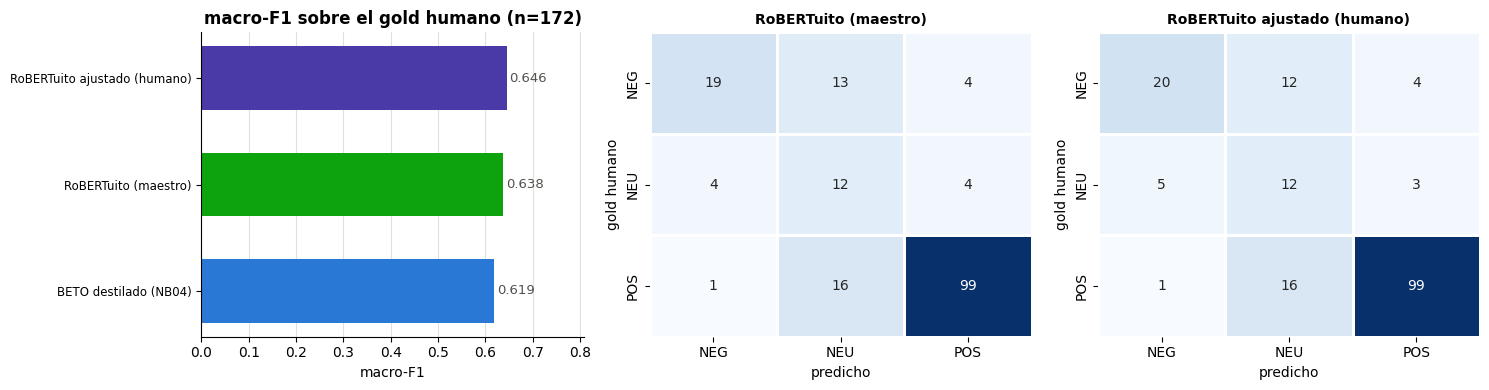

In [7]:
# Visualización: desempeño y matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

COL = {"RoBERTuito (maestro)": "#0ca30c", "BETO destilado (NB04)": "#2a78d6",
       "RoBERTuito ajustado (humano)": "#4a3aa7"}
barras = axes[0].barh(tabla.index, tabla["macro_F1"],
                      color=[COL.get(m, "#898781") for m in tabla.index], height=0.6)
for bb, v in zip(barras, tabla["macro_F1"]):
    axes[0].text(v + 0.005, bb.get_y()+bb.get_height()/2, f"{v:.3f}", va="center",
                 fontsize=9.5, color=INK2)
axes[0].set_xlim(0, tabla["macro_F1"].max()*1.25)
axes[0].set_title(f"macro-F1 sobre el gold humano (n={len(gold)})")
axes[0].set_xlabel("macro-F1"); axes[0].grid(axis="y", visible=False)
axes[0].tick_params(axis="y", labelsize=8.5)

for ax, n in zip(axes[1:], ["RoBERTuito (maestro)", "RoBERTuito ajustado (humano)"]):
    cm = confusion_matrix(gold["gold"], pred[n], labels=ORDEN)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ORDEN, yticklabels=ORDEN,
                cbar=False, linewidths=1, linecolor="white", ax=ax)
    ax.set_title(n, fontsize=10); ax.set_xlabel("predicho"); ax.set_ylabel("gold humano")
plt.tight_layout(); plt.show()

## 7 · Guardar el modelo

In [8]:
import json
destino = RAIZ/"analisis_sentimientos"/"models"/"modelo_sentimiento_humano"
entrenador.save_model(str(destino)); tok.save_pretrained(str(destino))

(destino/"info.json").write_text(json.dumps({
    "modelo_base": MAESTRO,
    "metodo": "continued fine-tuning con etiquetas humanas (sin destilacion)",
    "origen_etiquetas": "anotacion humana del equipo, 3 anotadores, alpha Krippendorff 0.585",
    "clases": ORDEN,
    "n_entrenamiento": int(len(tr)), "n_validacion": int(len(va)), "n_evaluacion": int(len(gold)),
    "hiperparametros": {"epocas": 4, "learning_rate": 1e-5, "batch_size": 8,
                        "max_length": 128, "perdida": "entropia cruzada ponderada por clase"},
    "metricas_gold_humano": {
        "macro_f1_ajustado": round(float(f1_h), 4),
        "macro_f1_maestro": round(float(f1_m), 4),
        "mcnemar_p": round(float(p_val), 4),
    },
    "dispositivo": DEVICE, "semilla": SEED,
}, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Modelo guardado en: {destino.relative_to(RAIZ)}")
for f in sorted(destino.glob("*")):
    if f.is_file(): print(f"  {f.name:26} {f.stat().st_size/1e6:>7.1f} MB")
print("\nUso:")
print('  from transformers import pipeline')
print(f'  clf = pipeline("sentiment-analysis", model="{destino.relative_to(RAIZ)}")')

Modelo guardado en: analisis_sentimientos/models/modelo_sentimiento_humano
  config.json                    0.0 MB
  info.json                      0.0 MB
  model.safetensors            435.2 MB
  tokenizer.json                 2.2 MB
  tokenizer_config.json          0.0 MB
  training_args.bin              0.0 MB

Uso:
  from transformers import pipeline
  clf = pipeline("sentiment-analysis", model="analisis_sentimientos/models/modelo_sentimiento_humano")


## 8 · Conclusiones

Completar con los resultados de las celdas anteriores. Guía de lectura:

- **§5** compara el modelo ajustado con el maestro y con el destilado del notebook 04, sobre un
  conjunto de evaluación **humano** de 172 comentarios (8.6 veces el anterior).
- **§6** determina si la diferencia es **estadísticamente significativa** (McNemar). Es el
  criterio que decide si puede afirmarse *"superamos al maestro"*.

**Lo que cambia respecto al notebook 04.** Allí el techo era el maestro y la conclusión fue un
empate técnico inevitable. Aquí el techo lo fija la **calidad del etiquetado humano**
(α = 0.585, acuerdo moderado), de modo que sí existe margen real de mejora.

**Limitaciones que deben acompañar cualquier cifra de este notebook**

| Limitación | Efecto |
|---|---|
| Solo 148 ejemplos de entrenamiento | Riesgo alto de sobreajuste; el margen de mejora está acotado |
| El gold tiene 20 ítems NEU frente a 116 POS | Las métricas de NEU son inestables |
| α = 0.585 (acuerdo moderado) | Parte del error atribuido al modelo es en realidad ambigüedad del lenguaje |
| Los casos mixtos adversativos aún no tienen regla consensuada | Fuente conocida de ruido en el gold; su resolución mejoraría el techo |

**Siguiente iteración**: fijar la regla de los mixtos adversativos, reanotar ese subconjunto y
ampliar el corpus anotado. Cada mejora del etiquetado eleva el techo alcanzable por el modelo.

---
*Notebook 05 · línea de trabajo NLP · equipo Tech Tailors.*